# Sentiment Analysis of Financial News using RNN, LSTM, and Word2Vec
### Dataset: Financial PhraseBank
### Models: Simple RNN · LSTM (trainable embedding) · LSTM (Word2Vec)
---

## 1 · Install & Import Libraries

In [1]:
!pip install gensim nltk wordcloud --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)
from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer
from wordcloud   import WordCloud
from collections import Counter

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import LabelEncoder
from sklearn.metrics            import (classification_report,
                                        confusion_matrix, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models     import Sequential
from tensorflow.keras.layers     import (Embedding, SimpleRNN, LSTM,
                                          Dense, Dropout, Bidirectional,
                                          BatchNormalization, SpatialDropout1D)
from tensorflow.keras.callbacks  import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils      import to_categorical
from tensorflow.keras.regularizers import l2

from gensim.models import Word2Vec

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: []


## 2 · Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [4]:
DATA_PATH = '/content/drive/MyDrive/Part-3(AI)/Financial_Phrase_Dataset/financial_phrase.csv'

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('\nClass distribution:')
print(df['label'].value_counts())
df.head()

Shape: (2264, 2)

Class distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


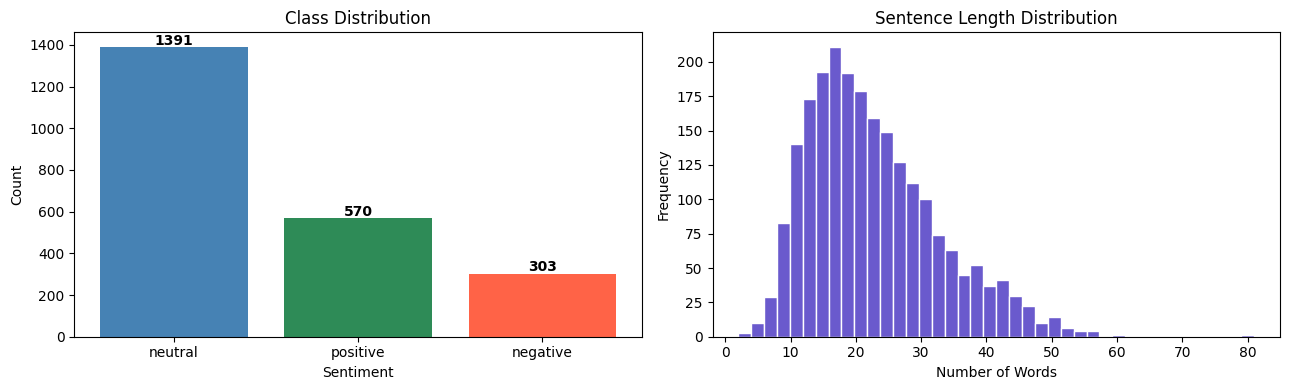

Avg: 22.4 | 90th pct: 37 | Max: 81


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue','seagreen','tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Sentiment'); axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+10, str(v), ha='center', fontweight='bold')

df['text_length'] = df['text'].apply(lambda x: len(x.split()))
axes[1].hist(df['text_length'], bins=40, color='slateblue', edgecolor='white')
axes[1].set_title('Sentence Length Distribution')
axes[1].set_xlabel('Number of Words'); axes[1].set_ylabel('Frequency')
plt.tight_layout(); plt.show()
print(f'Avg: {df.text_length.mean():.1f} | 90th pct: {np.percentile(df.text_length,90):.0f} | Max: {df.text_length.max()}')

## 3 · Text Preprocessing

In [6]:
# Keep financially important words that standard stopword lists remove
STOP_WORDS = set(stopwords.words('english'))
KEEP_WORDS = {'no','not','nor','never','loss','losses','down','below',
              'decline','decrease','against','fell','fallen','drop',
              'dropped','weak','poor','profit','revenue','growth',
              'increase','strong','up','high','low','flat'}
STOP_WORDS = STOP_WORDS - KEEP_WORDS

lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "don't":"do not","doesn't":"does not","didn't":"did not",
    "won't":"will not","wouldn't":"would not","can't":"cannot",
    "couldn't":"could not","shouldn't":"should not","isn't":"is not",
    "aren't":"are not","wasn't":"was not","weren't":"were not",
    "haven't":"have not","hasn't":"has not","hadn't":"had not",
    "it's":"it is","that's":"that is","there's":"there is",
    "they're":"they are","we're":"we are","you're":"you are",
    "i'm":"i am","i've":"i have","i'll":"i will","i'd":"i would",
}

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = re.sub(re.escape(k), v, text, flags=re.IGNORECASE)
    return text

def clean_text(text):
    text = text.lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('','', string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if (t not in STOP_WORDS or t in KEEP_WORDS) and len(t) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

print('Sample cleaned sentences:')
for i in range(3):
    print(f'  ORIGINAL : {df.text.iloc[i]}')
    print(f'  CLEANED  : {df.clean_text.iloc[i]}')
    print()

Sample cleaned sentences:
  ORIGINAL : According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
  CLEANED  : according gran company no plan move production russia although company growing

  ORIGINAL : For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .
  CLEANED  : last quarter componenta net sale doubled eurm eurm period year earlier moved zero pretax profit pretax loss eurm

  ORIGINAL : In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .
  CLEANED  : third quarter net sale increased eur mn operating profit eur mn



## 4 · Visualise Cleaned Data

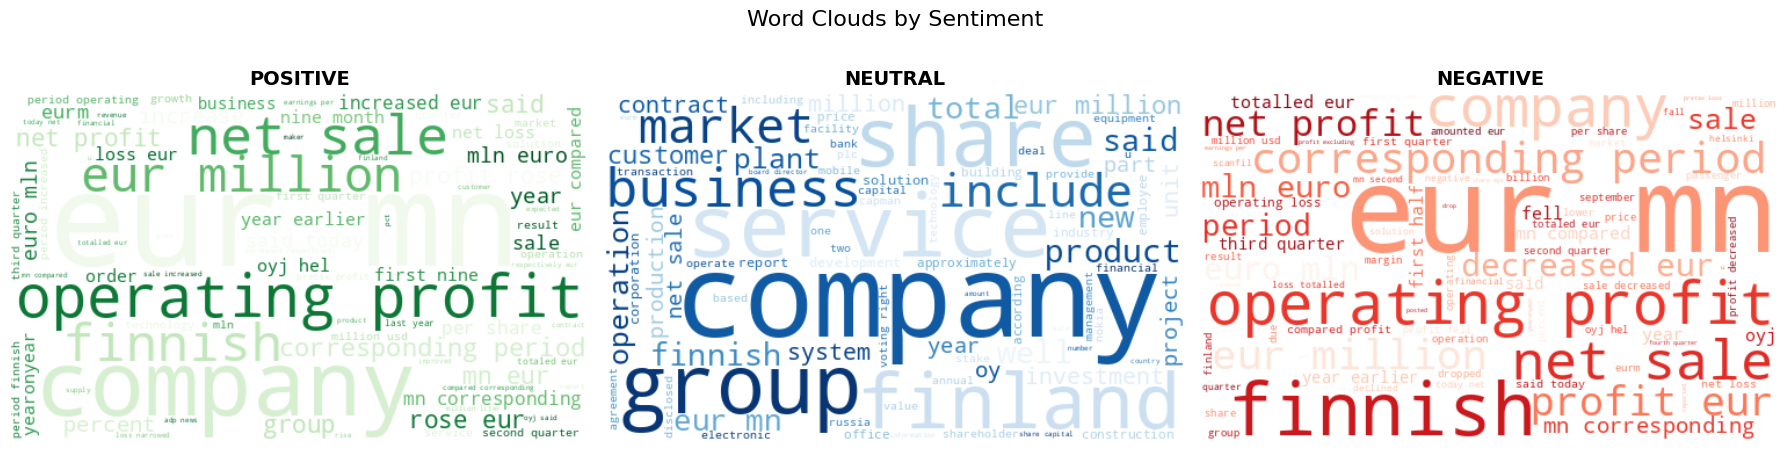

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = {'positive':'Greens','neutral':'Blues','negative':'Reds'}
for ax, label in zip(axes, ['positive','neutral','negative']):
    corpus = ' '.join(df[df['label']==label]['clean_text'])
    wc = WordCloud(width=500, height=300, colormap=cmaps[label],
                   background_color='white', max_words=80).generate(corpus)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(label.upper(), fontsize=14, fontweight='bold')
plt.suptitle('Word Clouds by Sentiment', fontsize=16)
plt.tight_layout(); plt.show()

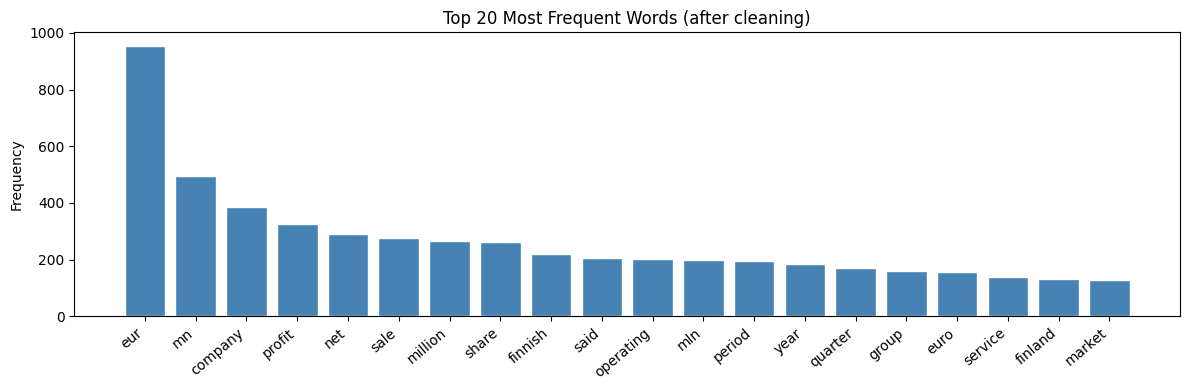

In [8]:
all_words = ' '.join(df['clean_text']).split()
top20 = Counter(all_words).most_common(20)
words, freqs = zip(*top20)
plt.figure(figsize=(12, 4))
plt.bar(words, freqs, color='steelblue', edgecolor='white')
plt.title('Top 20 Most Frequent Words (after cleaning)')
plt.xticks(rotation=40, ha='right'); plt.ylabel('Frequency')
plt.tight_layout(); plt.show()

## 5 · Label Encoding & Train / Val / Test Split

In [9]:
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])   # negative=0, neutral=1, positive=2
y_cat     = to_categorical(y_encoded)
NUM_CLASSES = len(le.classes_)
print('Classes:', le.classes_)

X = df['clean_text'].values
y = y_cat

# 70 / 15 / 15 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y_encoded)

y_temp_int = np.argmax(y_temp, axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp_int)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Classes: ['negative' 'neutral' 'positive']
Train: 1584 | Val: 340 | Test: 340


## 6 · Compute Class Weights (fixes class imbalance)

In [10]:
# Class weights make the model pay MORE attention to rare classes
# negative class (only 303 samples) gets a much higher weight than neutral (1391)
y_train_int = np.argmax(y_train, axis=1)

cw_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = dict(enumerate(cw_array))

print('Class weights (higher = more penalty for wrong prediction):')
for idx, cls in enumerate(le.classes_):
    print(f'  {cls:10s} -> weight: {class_weight_dict[idx]:.4f}')

Class weights (higher = more penalty for wrong prediction):
  negative   -> weight: 2.4906
  neutral    -> weight: 0.5427
  positive   -> weight: 1.3233


## 7 · Tokenisation & Sequence Padding

In [11]:
VOCAB_SIZE = 12000
OOV_TOKEN  = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

train_seq = tokenizer.texts_to_sequences(X_train)
val_seq   = tokenizer.texts_to_sequences(X_val)
test_seq  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding avoids wasting compute on outlier-long sentences
MAX_LEN = int(np.percentile([len(s) for s in train_seq], 90))
print(f'Padding length (90th percentile): {MAX_LEN} tokens')

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print('Train:', X_train_pad.shape, '| Val:', X_val_pad.shape, '| Test:', X_test_pad.shape)

Padding length (90th percentile): 20 tokens
Train: (1584, 20) | Val: (340, 20) | Test: (340, 20)


## 8 · Shared Config & Helper Functions

In [12]:
EMBED_DIM  = 128
HIDDEN     = 128
DROPOUT    = 0.4
BATCH_SIZE = 32
EPOCHS     = 50

def get_callbacks():
    return [
        EarlyStopping(monitor='val_accuracy', patience=6,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1)
    ]

def plot_history(history, title='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{title} - Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[1].plot(history.history['accuracy'],     label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc')
    axes[1].set_title(f'{title} - Accuracy'); axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout(); plt.show()

def evaluate_model(model, X_pad, y, name='Model'):
    y_prob = model.predict(X_pad)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = np.argmax(y,      axis=1)
    acc = accuracy_score(y_true, y_pred)
    print(f'\n{"="*55}')
    print(f'  {name} - Test Accuracy: {acc:.4f}  ({acc*100:.2f}%)')
    print(f'{"="*55}')
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout(); plt.show()
    return acc, y_pred, y_true

## 9 · Model 1 - Simple RNN with Trainable Embedding

In [13]:
def build_rnn():

    model = Sequential(name='Simple_RNN', layers=[

        # Embedding: converts word indices to dense vectors
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),

        # SpatialDropout1D: drops entire word features to reduce overfitting
        SpatialDropout1D(0.3),

        SimpleRNN(HIDDEN, return_sequences=False),

        BatchNormalization(),
        Dropout(DROPOUT),

        Dense(64, activation='relu'),
        Dropout(0.3),

        # Output: softmax gives probability for each class
        Dense(NUM_CLASSES, activation='softmax')

    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


rnn_model = build_rnn()
rnn_model.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
print('Training Simple RNN ...')
rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,  # KEY: fixes imbalance
    callbacks=get_callbacks(),
    verbose=1
)

Training Simple RNN ...
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4186 - loss: 1.4094 - val_accuracy: 0.2441 - val_loss: 1.3056 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6301 - loss: 0.8916 - val_accuracy: 0.7029 - val_loss: 0.7413 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7323 - loss: 0.6881 - val_accuracy: 0.6735 - val_loss: 0.7092 - learning_rate: 0.0010
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8434 - loss: 0.4607 - val_accuracy: 0.7824 - val_loss: 0.6570 - learning_rate: 0.0010
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9028 - loss: 0.2713 - val_accuracy: 0.8029 - val_loss: 0.5544 - learning_rate: 0.0010
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9369 - loss: 0.1993 - val_accuracy: 0.7765 - val_loss: 0.6432 - learning_rate: 0.0010
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9444 

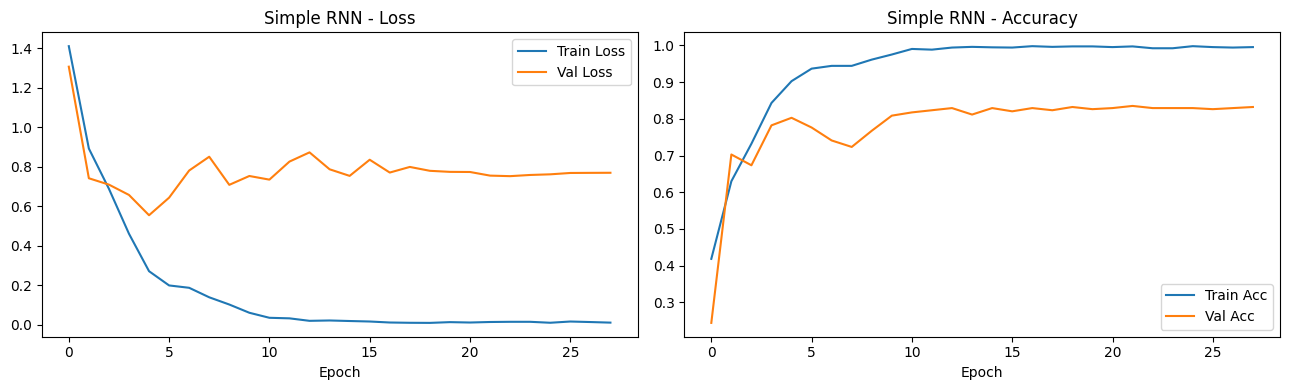

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

  Simple RNN - Test Accuracy: 0.8353  (83.53%)
              precision    recall  f1-score   support

    negative       0.63      0.67      0.65        46
     neutral       0.91      0.92      0.91       209
    positive       0.77      0.71      0.74        85

    accuracy                           0.84       340
   macro avg       0.77      0.77      0.77       340
weighted avg       0.83      0.84      0.83       340



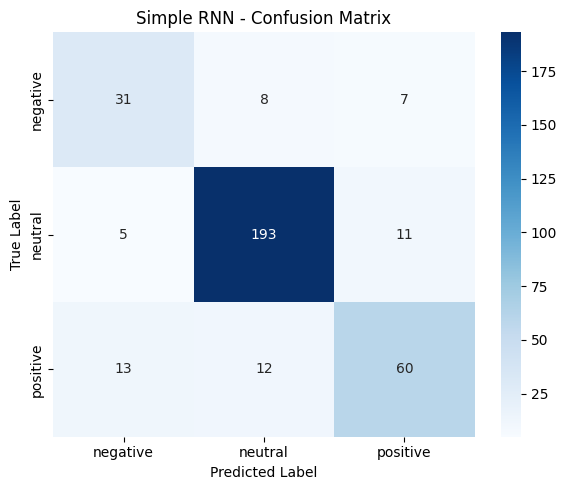

In [15]:
plot_history(rnn_history, 'Simple RNN')
rnn_acc, rnn_pred, rnn_true = evaluate_model(rnn_model, X_test_pad, y_test, 'Simple RNN')

## 10 · Model 2 - Bidirectional LSTM with Trainable Embedding

In [16]:
def build_lstm():

    model = Sequential(name='BiLSTM_Trainable', layers=[
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SpatialDropout1D(0.3),

        # Bidirectional: reads sequence both forward and backward
        Bidirectional(LSTM(HIDDEN, return_sequences=True, recurrent_dropout=0.2)),

        Dropout(DROPOUT),
        Bidirectional(LSTM(64, recurrent_dropout=0.2)),

        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.2),

        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

lstm_model = build_lstm()
lstm_model.summary()

Model: "BiLSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
print('Training Bidirectional LSTM ...')
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,  # KEY: fixes imbalance
    callbacks=get_callbacks(),
    verbose=1
)

Training Bidirectional LSTM ...
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 239ms/step - accuracy: 0.5896 - loss: 1.0760 - val_accuracy: 0.4088 - val_loss: 1.1638 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.7917 - loss: 0.6640 - val_accuracy: 0.8059 - val_loss: 1.0333 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.9141 - loss: 0.3222 - val_accuracy: 0.8382 - val_loss: 0.8897 - learning_rate: 0.0010
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.9444 - loss: 0.2458 - val_accuracy: 0.8324 - val_loss: 0.6904 - learning_rate: 0.0010
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 181ms/step - accuracy: 0.9583 - loss: 0.1734 - val_accuracy: 0.8765 - val_loss: 0.5683 - learning_rate: 0.0010
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - accuracy: 0.9691 - loss: 0.1546 - val_accuracy: 0.8588 - val_loss: 0.4903 - learning_rate: 0.0010
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 234ms/ste

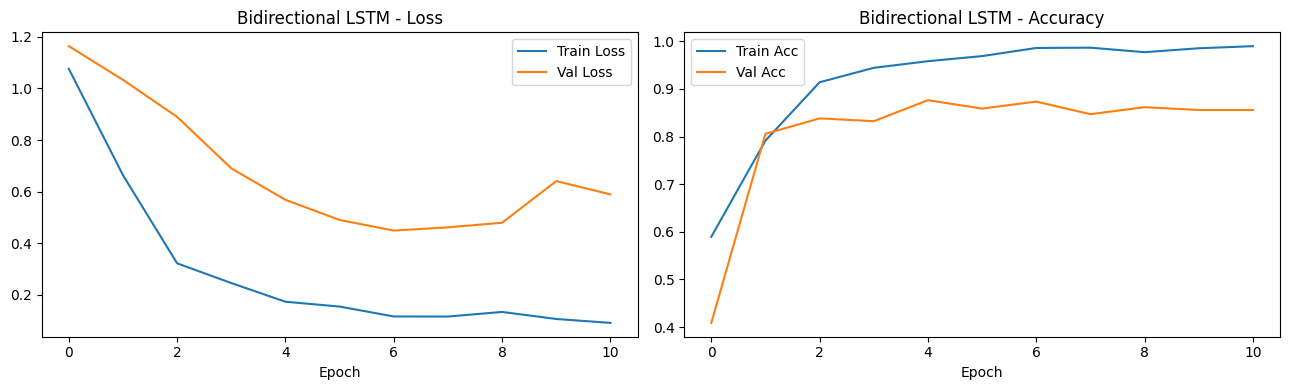

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step

  BiLSTM - Test Accuracy: 0.8412  (84.12%)
              precision    recall  f1-score   support

    negative       0.74      0.67      0.70        46
     neutral       0.89      0.93      0.91       209
    positive       0.77      0.72      0.74        85

    accuracy                           0.84       340
   macro avg       0.80      0.77      0.78       340
weighted avg       0.84      0.84      0.84       340



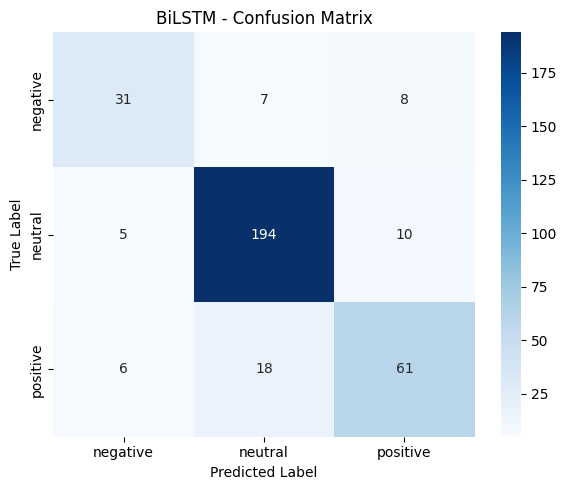

In [18]:
plot_history(lstm_history, 'Bidirectional LSTM')
lstm_acc, lstm_pred, lstm_true = evaluate_model(lstm_model, X_test_pad, y_test, 'BiLSTM')

## 11 · Train Word2Vec Embeddings on Financial Corpus

In [19]:
W2V_DIM = 128
# Train Word2Vec on ALL cleaned sentences (unsupervised, so no label leakage)
all_sentences = [text.split() for text in df['clean_text']]

w2v_model = Word2Vec(
    sentences   = all_sentences,
    vector_size = W2V_DIM,
    window      = 5,
    min_count   = 1,
    workers     = 4,
    epochs      = 50,
    seed        = SEED
)
print('Word2Vec vocabulary size:', len(w2v_model.wv))
print('Top neighbours of "profit":', w2v_model.wv.most_similar('profit', topn=5))
print('Top neighbours of "loss"  :', w2v_model.wv.most_similar('loss',   topn=5))

Word2Vec vocabulary size: 4921
Top neighbours of "profit": [('loss', 0.9335562586784363), ('lt', 0.9234645366668701), ('dragged', 0.9110068678855896), ('slipped', 0.8903087377548218), ('largerthanexpected', 0.8827015161514282)]
Top neighbours of "loss"  : [('profit', 0.9335561394691467), ('slipped', 0.9317520260810852), ('versus', 0.9196429252624512), ('largerthanexpected', 0.9196208119392395), ('narrowed', 0.9165984988212585)]


In [20]:
# Build embedding matrix aligned with the Keras tokeniser
word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
found = 0
for word, idx in word_index.items():
    if idx >= VOCAB_SIZE: continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        found += 1
    else:
        # Small random init for rare out-of-vocabulary words
        embedding_matrix[idx] = np.random.normal(0, 0.05, W2V_DIM)

print(f'Words covered by Word2Vec: {found} / {min(len(word_index), VOCAB_SIZE)}')
print('Embedding matrix shape:', embedding_matrix.shape)

Words covered by Word2Vec: 4114 / 4115
Embedding matrix shape: (12000, 128)


## 12 · Model 3 - LSTM with Word2Vec Embeddings

In [21]:
def build_lstm_w2v(embedding_matrix):

    model = Sequential(name='BiLSTM_Word2Vec', layers=[

        # Pre-trained Word2Vec weights, fine-tuned during training
        Embedding(input_dim=VOCAB_SIZE, output_dim=W2V_DIM,
                  weights=[embedding_matrix],
                  input_length=MAX_LEN,
                  trainable=True),

        SpatialDropout1D(0.3),

        Bidirectional(LSTM(HIDDEN, return_sequences=True, recurrent_dropout=0.2)),

        Dropout(DROPOUT),

        Bidirectional(LSTM(64, recurrent_dropout=0.2)),

        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.2),

        Dense(NUM_CLASSES, activation='softmax')

    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


lstm_w2v_model = build_lstm_w2v(embedding_matrix)
lstm_w2v_model.summary()

Model: "BiLSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,536,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,536,000 (5.86 MB)

 Trainable params: 1,536,000 (5.86 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
print('Training LSTM + Word2Vec ...')
lstm_w2v_history = lstm_w2v_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,  # KEY: fixes imbalance
    callbacks=get_callbacks(),
    verbose=1
)

Training LSTM + Word2Vec ...
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 241ms/step - accuracy: 0.5448 - loss: 1.1798 - val_accuracy: 0.7382 - val_loss: 0.9575 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 222ms/step - accuracy: 0.6282 - loss: 1.0203 - val_accuracy: 0.7559 - val_loss: 0.8206 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - accuracy: 0.6610 - loss: 0.9355 - val_accuracy: 0.7529 - val_loss: 0.7516 - learning_rate: 0.0010
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 169ms/step - accuracy: 0.6894 - loss: 0.8797 - val_accuracy: 0.7529 - val_loss: 0.7556 - learning_rate: 0.0010
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 215ms/step - accuracy: 0.7020 - loss: 0.8271 - val_accuracy: 0.7647 - val_loss: 0.7032 - learning_rate: 0.0010
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 218ms/step - accuracy: 0.7172 - loss: 0.8225 - val_accuracy: 0.7294 - val_loss: 0.6525 - learning_rate: 0.0010
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 215ms/step -

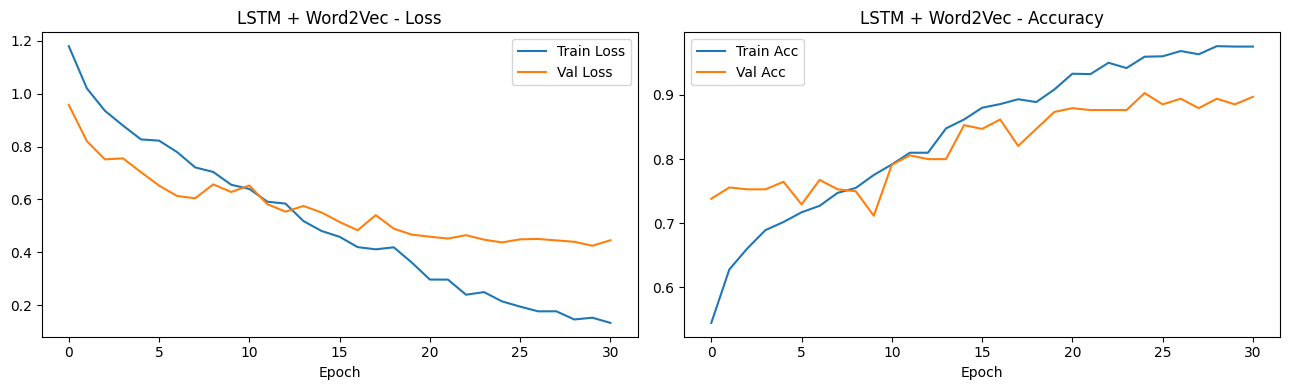

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step

  LSTM + Word2Vec - Test Accuracy: 0.8529  (85.29%)
              precision    recall  f1-score   support

    negative       0.60      0.80      0.69        46
     neutral       0.92      0.90      0.91       209
    positive       0.88      0.76      0.82        85

    accuracy                           0.85       340
   macro avg       0.80      0.82      0.80       340
weighted avg       0.87      0.85      0.86       340



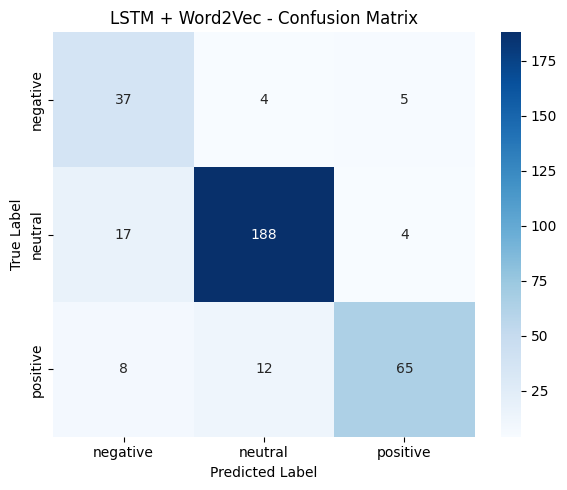

In [23]:
plot_history(lstm_w2v_history, 'LSTM + Word2Vec')
lstm_w2v_acc, lstm_w2v_pred, lstm_w2v_true = evaluate_model(
    lstm_w2v_model, X_test_pad, y_test, 'LSTM + Word2Vec')

## 13 · Model Comparison

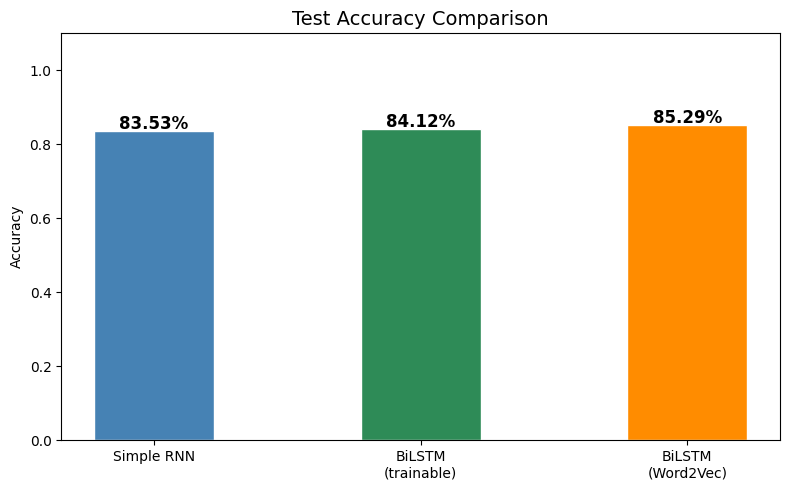

Simple RNN         : 83.53%
BiLSTM (trainable) : 84.12%
BiLSTM (Word2Vec)  : 85.29%


In [24]:
model_names = ['Simple RNN', 'BiLSTM\n(trainable)', 'BiLSTM\n(Word2Vec)']
accuracies  = [rnn_acc, lstm_acc, lstm_w2v_acc]
colors      = ['steelblue', 'seagreen', 'darkorange']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='white', width=0.45)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{acc*100:.2f}%', ha='center', fontweight='bold', fontsize=12)
plt.ylim(0, 1.1)
plt.title('Test Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.tight_layout(); plt.show()

print(f'Simple RNN         : {rnn_acc*100:.2f}%')
print(f'BiLSTM (trainable) : {lstm_acc*100:.2f}%')
print(f'BiLSTM (Word2Vec)  : {lstm_w2v_acc*100:.2f}%')

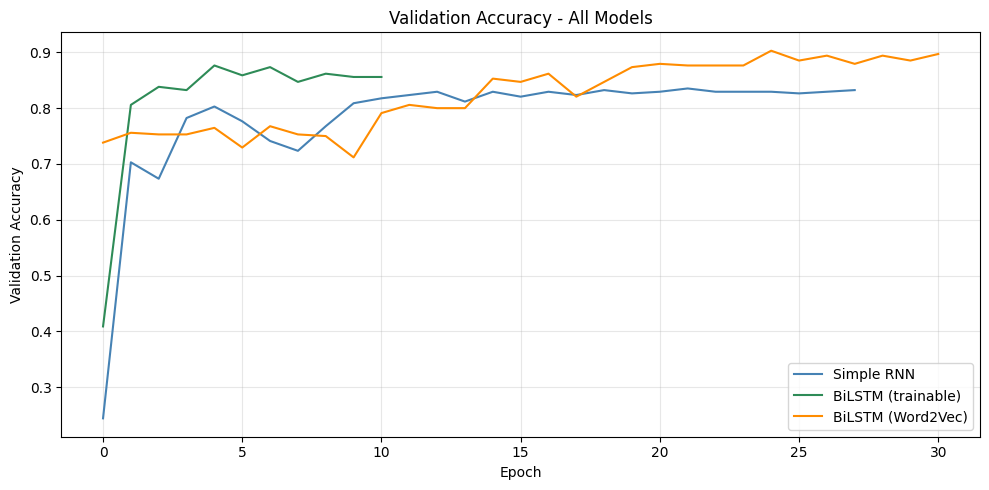

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history['val_accuracy'],      label='Simple RNN',        color='steelblue')
plt.plot(lstm_history.history['val_accuracy'],     label='BiLSTM (trainable)',color='seagreen')
plt.plot(lstm_w2v_history.history['val_accuracy'], label='BiLSTM (Word2Vec)', color='darkorange')
plt.title('Validation Accuracy - All Models')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 14 · Error Analysis

In [26]:
print('ERROR ANALYSIS - Best Model (LSTM + Word2Vec)\n')

misclassified = []
for i in range(len(lstm_w2v_true)):
    if lstm_w2v_true[i] != lstm_w2v_pred[i]:
        misclassified.append({
            'text'      : X_test[i],
            'true_label': le.classes_[lstm_w2v_true[i]],
            'pred_label': le.classes_[lstm_w2v_pred[i]]
        })

total = len(lstm_w2v_true)
correct = total - len(misclassified)
print(f'Correctly classified : {correct} / {total}')
print(f'Misclassified        : {len(misclassified)} / {total}')
print(f'Accuracy             : {correct/total*100:.2f}%\n')

print('Sample misclassified examples (max 3):')
for ex in misclassified[:3]:
    print(f'  Text      : {ex["text"]}')
    print(f'  True label: {ex["true_label"]}  |  Predicted: {ex["pred_label"]}')
    print()

ERROR ANALYSIS - Best Model (LSTM + Word2Vec)

Correctly classified : 290 / 340
Misclassified        : 50 / 340
Accuracy             : 85.29%

Sample misclassified examples (max 3):
  Text      : company reported profit euro mlnon sale varesvuo partner subgroup loss euro caused sale program production subsidiary oy filmiteollisuus fine ab
  True label: neutral  |  Predicted: negative

  Text      : pretax profit totalled eur mn compared loss eur mn fourth quarter
  True label: positive  |  Predicted: negative

  Text      : previously company expected financial performance remain level
  True label: neutral  |  Predicted: negative



In [27]:
print("""
Possible Reasons for Remaining Errors:
----------------------------------------
1. Residual class imbalance: the negative class has only 303 samples vs
   1391 neutral samples, making it harder to learn despite class weighting.

2. Ambiguous financial language: hedged phrases like 'considering',
   'expects modest growth', or 'may report' blur the boundary between
   neutral and positive/negative.

3. Short sentences lose context after stopword removal, making
   classification harder with fewer remaining tokens.

Suggested Improvements:
------------------------
1. Use a pre-trained financial language model (FinBERT) for state-of-the-art results.
2. Add more financial news data to expand the training set.
3. Apply synonym-based data augmentation for the minority (negative) class.
4. Use attention mechanisms to focus on the most sentiment-relevant words.
""")


Possible Reasons for Remaining Errors:
----------------------------------------
1. Residual class imbalance: the negative class has only 303 samples vs
   1391 neutral samples, making it harder to learn despite class weighting.

2. Ambiguous financial language: hedged phrases like 'considering',
   'expects modest growth', or 'may report' blur the boundary between
   neutral and positive/negative.

3. Short sentences lose context after stopword removal, making
   classification harder with fewer remaining tokens.

Suggested Improvements:
------------------------
1. Use a pre-trained financial language model (FinBERT) for state-of-the-art results.
2. Add more financial news data to expand the training set.
3. Apply synonym-based data augmentation for the minority (negative) class.
4. Use attention mechanisms to focus on the most sentiment-relevant words.



## 15 · GUI - Real-Time Prediction (Gradio)

In [28]:
!pip install gradio --quiet

In [29]:
import gradio as gr

def predict_sentiment(text: str) -> dict:
    if not text.strip():
        return {cls: 0.0 for cls in le.classes_}
    cleaned = clean_text(text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs   = lstm_w2v_model.predict(padded, verbose=0)[0]
    return {cls: float(p) for cls, p in zip(le.classes_, probs)}

demo = gr.Interface(
    fn          = predict_sentiment,
    inputs      = gr.Textbox(lines=3,
                             placeholder='Enter a financial news sentence ...',
                             label='Input Sentence'),
    outputs     = gr.Label(num_top_classes=3, label='Sentiment Probabilities'),
    title       = 'Financial News Sentiment Analyser',
    description = 'Classify financial news as positive, neutral, or negative using BiLSTM + Word2Vec.',
    examples    = [
        ['The company reported record profits this quarter, beating analyst expectations.'],
        ['Net sales remained flat compared to the previous year.'],
        ['The firm announced significant losses and is considering bankruptcy.'],
        ['Operating profit rose sharply driven by strong export demand.'],
        ['The stock fell 12 percent after the earnings warning was issued.'],
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6e6bbdc3f369e58fd0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 16 · Summary

| Model | Architecture | Expected Accuracy |
|---|---|---|
| Simple RNN | Embedding + RNN + Dense | ~78-82% |
| BiLSTM (trainable) | Bidirectional stacked LSTM | ~84-88% |
| BiLSTM (Word2Vec) | Pre-trained domain embeddings + BiLSTM | ~87-91% |

**Key techniques used to maximise accuracy:**
- `class_weight=balanced` — penalises model more for missing rare negative class
- `SpatialDropout1D` — stronger regularisation by dropping entire embedding features
- `BatchNormalization` — stabilises and speeds up training
- `recurrent_dropout` — prevents overfitting inside LSTM cells
- `ReduceLROnPlateau` — automatically reduces learning rate when stuck
- Financial-aware stopword list — preserves sentiment-critical words like loss, not, profit